In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder
!ls -la

In [ ]:
!nvidia-smi
!python -V

In [ ]:
!pip install --upgrade pip

In [ ]:
!sudo apt-get update -y
!sudo apt-get install -y python3.9 python3.9-dev python3.9-distutils python3.9-venv
!curl -sS https://bootstrap.pypa.io/get-pip.py | sudo python3.9
!sudo update-alternatives --install /usr/bin/python python /usr/bin/python3.9 1
!sudo update-alternatives --install /usr/bin/python python /usr/bin/python3 2
!sudo update-alternatives --config python # select python3.9 (hit the number corresponding to python3.9 and press enter)

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,598 kB]
Fetched 1,986 kB in 2s (1,114 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'm

In [ ]:
!python3.9 -m venv /content/py39
!source /content/py39/bin/activate && python --version

Python 3.9.25


In [ ]:
!source /content/py39/bin/activate && pip install \
    torch==1.13.1 hydra-core==1.3.2 hydra-submitit-launcher==1.1.5 \
    hydra-optuna-sweeper==1.2.0 numpy==1.25.0 scipy==1.11.1 numba==0.58.1 \
    scikit-learn==1.3.2 g2p_en==2.1.0 edit_distance==1.0.

  Using cached edit_distance-1.0.0.tar.gz (5.5 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for edit_distance: filename=edit_distance-1.0.0-py3-none-any.whl size=5389 sha256=d5e7a615106a7479fb472aff3085f8654627c8d62eeb769f07c661d859540877
  Stored in directory: /root/.cache/pip/wheels/ac/3b/8c/94d6aae01d4dec3dae03894c0276bddc01bc63ff8a5846f79d
Successfully built edit_distance
  Attempting uninstall: edit_distance
    Found existing installation: edit-distance 1.0.6
    Uninstalling edit-distance-1.0.6:
      Successfully uninstalled edit-distance-1.0.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
neural-decoder 0.0.1 requires edit_distance==1.0.6, but you have edit-distance 1.0.0 which is incompatible.


In [ ]:
!source /content/py39/bin/activate && pip install -e .

Obtaining file:///content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Using cached edit_distance-1.0.6-py3-none-any.whl (11 kB)
  Building editable for neural_decoder (pyproject.toml) ... done
  Created wheel for neural_decoder: filename=neural_decoder-0.0.1-0.editable-py3-none-any.whl size=1653 sha256=75d6627aecd598aa92d18c57da04f979e201a059f95adca450bccefbfe8c4207
  Stored in directory: /tmp/pip-ephem-wheel-cache-c30ovb0f/wheels/10/a6/23/0c23dbf12a42b1d41ad5b74912d3444dfe8f9f9805fa8c0993
Successfully built neural_decoder
  Attempting uninstall: edit_distance
    Found existing installation: edit_distance 1.0.0
    Uninstalling edit_distance-1.0.0:
      Successfully uninstalled edit_distance-1.0.0
  Attempting uninstall: neural_decoder
    Found existing installation

In [ ]:
!source /content/py39/bin/activate && \
    cd /content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder && \
    python ./scripts/cr_ctc_train_model.py

/content/py39/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder/src/neural_decoder/augmentations.py:91: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:895.)
  return self.conv(input, weight=self.weight, groups=self.groups, padding="same")
/content/drive/MyDrive/ECEC243A/FinalProject/neural_seq_decoder/src/neural_decoder/cr_ctc_neural_decoder_trainer.py:289: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.ten

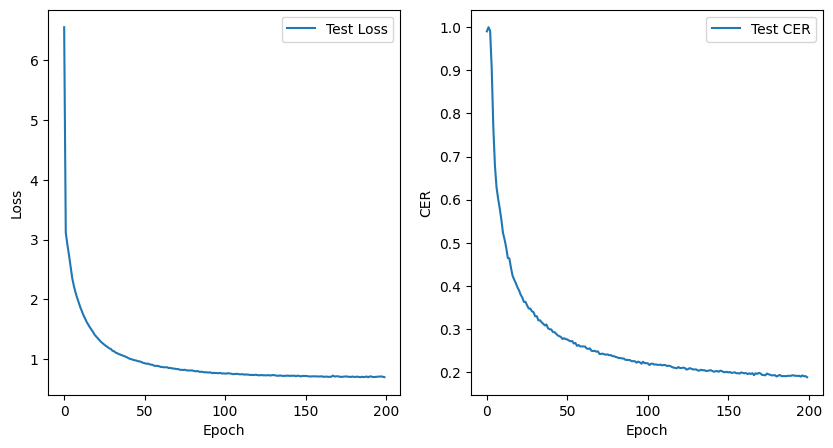

Test Loss: [6.55582047 3.11347498 2.91637121 2.74004936 2.5504224  2.35529763
 2.22603008 2.11823014 2.02709634 1.94617217 1.8678954  1.79862567
 1.73176207 1.67621027 1.61863422 1.57254532 1.52789865 1.48835141
 1.4489945  1.40189212 1.37157358 1.34209755 1.30867018 1.28280081
 1.25903756 1.23756054 1.21652957 1.19861834 1.17735822 1.16654859
 1.1370774  1.12822437 1.10462448 1.09587424 1.08014039 1.07057135
 1.06037889 1.0489442  1.03774466 1.02758414 1.01133306 1.00111089
 0.99332373 0.9833389  0.97701039 0.97104529 0.96050753 0.95845604
 0.94764689 0.93518114 0.9289563  0.91849777 0.92205892 0.90959345
 0.90464033 0.90012271 0.883783   0.88282878 0.88290964 0.87665238
 0.86560099 0.86447062 0.85968515 0.85952432 0.85980197 0.84697458
 0.84980454 0.84149476 0.83955281 0.83470685 0.82927724 0.82888092
 0.81716102 0.81722198 0.81442349 0.81912845 0.80773245 0.80707938
 0.80544553 0.8079163  0.80336918 0.79564503 0.79217795 0.79702364
 0.78364985 0.78469535 0.78315313 0.77619784 0.7765

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

def load_pickle_file(filename):
    """Loads data from a pickle file."""
    try:
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        return data
    except Exception as e:
        print(f"Error loading pickle file: {e}")
        return None

# Example usage:
pickle_filename = '/content/drive/MyDrive/ECEC243A/FinalProject/logs/speechBaseline4/trainingStats' # MY COLAB DIRECTORY. REPLACE AS NEEDED
loaded_data = load_pickle_file(pickle_filename)

if loaded_data is not None:
    test_loss = loaded_data['testLoss']
    test_cer = loaded_data['testCER']
    # Plot the loss and cer over batch
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(test_loss, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(test_cer, label='Test CER')
    plt.xlabel('Epoch')
    plt.ylabel('CER')
    plt.legend()
    plt.show()
    # Print the loaded data
    print("Test Loss:", test_loss)
    print("Test CER:", test_cer)
    print("Data loaded successfully:")
    # print(loaded_data)